# 🏏 IPL 2022 Capstone Project

The **Indian Premier League (IPL)** is a professional T20 cricket league in India, 
featuring franchises representing cities. This project explores **IPL 2022 match-level 
data** to derive meaningful insights and understand match outcomes, player performances, 
and team dynamics.

---

## 📋 Dataset Overview

These are the important columns we'll focus on for meaningful insights:

| Column | Type |
|---|---|
| `date` | string |
| `venue` | string |
| `stage` | string |
| `team1` | string |
| `team2` | string |
| `toss_winner` | string |
| `toss_decision` | string |
| `first_ings_score` | integer |
| `second_ings_score` | integer |
| `match_winner` | string |
| `won_by` | string |
| `margin` | integer |
| `player_of_the_match` | string |
| `top_scorer` | string |
| `highscore` | integer |
| `best_bowling` | string |
| `best_bowling_figure` | string |

<h4><b> Loading Dataset And Libraries </b></h4>

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import plotly.express as px

warnings.filterwarnings("ignore")

In [17]:
df=pd.read_csv("IPL.csv")
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


<h3 style="font-weight:500;">  Basic Information  </h3>

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

<h5 style="font-weight:500;">  Check the size of rows and columns  </h5>

In [12]:
print(f"The size of row is: {df.shape[0]} and the size of column is: {df.shape[1]}")

The size of row is: 74 and the size of column is: 20


<h5 style="font-weight:500;">  Check how many columns have null value in total  </h5>

In [16]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

<h5 style="font-weight:500;">  Here comes some basic questions  </h5>

<p style="font-weight:500; font-size:17px">  1. Which team one the most matches  </p>

Text(0.5, 1.0, 'most match win by team')

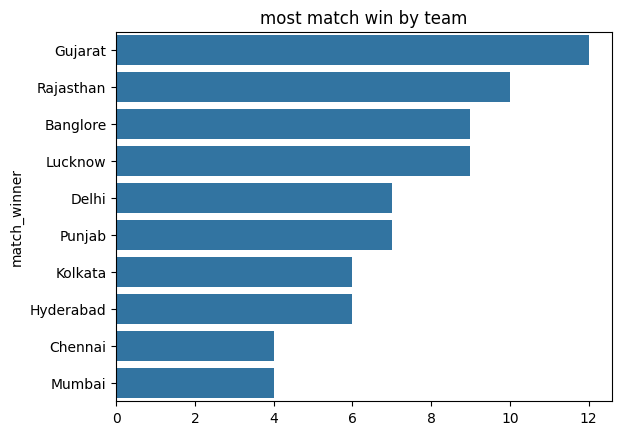

In [34]:
match_winner=df['match_winner'].value_counts()
sns.barplot(y=match_winner.index,x=match_winner.values)
plt.title("most match win by team")


In [32]:
match_winner=df['match_winner'].value_counts()

fig=px.bar(match_winner,y=match_winner.index,x=match_winner.values,color_discrete_sequence=["orange"],title="most match win by team")
fig.show()

<p style="font-weight:500; font-size:17px">  2. Toss Decision Trends  </p>

<Axes: xlabel='toss_decision', ylabel='count'>

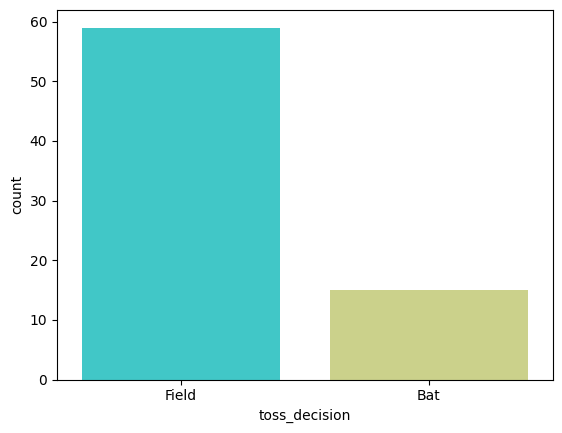

In [38]:
sns.countplot(x=df['toss_decision'],palette="rainbow")

<p style="font-weight:500; font-size:17px">  3. Toss Winner vs Match Winner  </p>

In [54]:
count=df[df['toss_winner']==df['match_winner']]['match_id'].count()
percentage=(count*100)/df.shape[0]
percentage.round(2).item()

48.65

<p style="font-weight:500; font-size:17px">  4. How do teams wins  </p>

<Axes: xlabel='won_by', ylabel='count'>

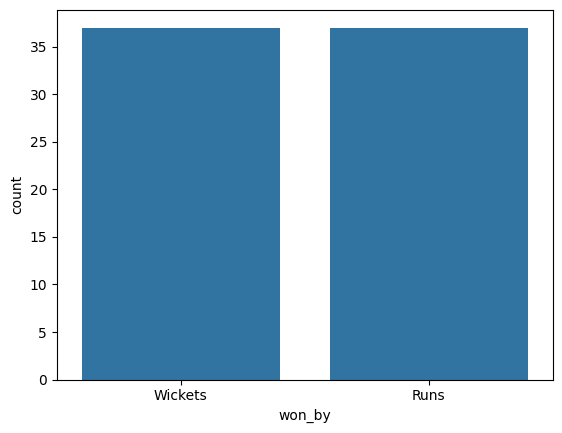

In [ ]:
df['won_by']
sns.countplot(x=df['won_by'])

In [61]:
fig=px.histogram(df,x="won_by",title="How do team wins Wickets vs Runs")
fig.show()

<h5 style="font-weight:500;">  Key Player Performances  </h5>

<p style="font-weight:500; font-size:17px">  1. Most player of the match awards  </p>

<Axes: ylabel='player_of_the_match'>

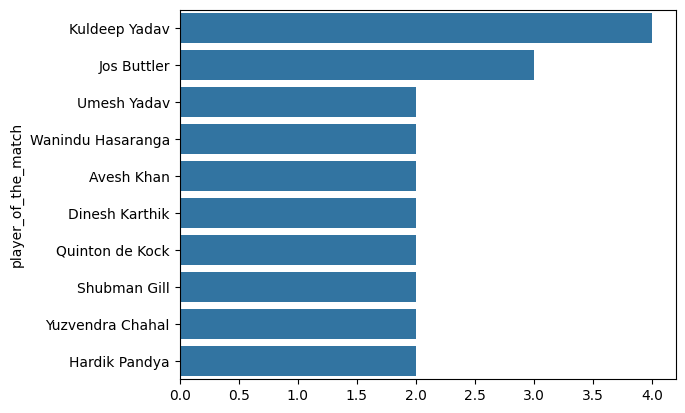

In [72]:
count=df['player_of_the_match'].value_counts().head(10)
sns.barplot(y=count.index,x=count.values)

In [82]:
count=df['player_of_the_match'].value_counts().head(10)

fig=px.bar(count,y=count.index,x=count.values,color_discrete_sequence=["orange"],title="most player of the match")
fig.show()

<p style="font-weight:500; font-size:17px">  2. Top scorers  </p>

<Axes: xlabel='top_scorer'>

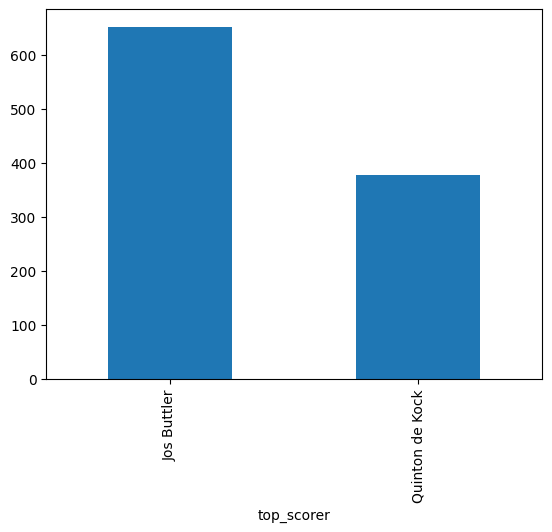

In [100]:
high=df.groupby("top_scorer")["highscore"].sum().sort_values(ascending=False).head(2)
high

high.plot(kind="bar")
# fig=px.bar(count,y=count.index,x=count.values,color_discrete_sequence=["orange"],title="Top Scorers in IPL")
# fig.show()

In [102]:
high=df.groupby("top_scorer")["highscore"].sum().sort_values(ascending=False).head(2)
high

fig=px.bar(high,x=high.index,y=high.values,color_discrete_sequence=["orange"],title="Top Two Scorers in IPL")
fig.show()

<p style="font-weight:500; font-size:17px">  3. Best Bowling Figures  </p>

<Axes: ylabel='best_bowling'>

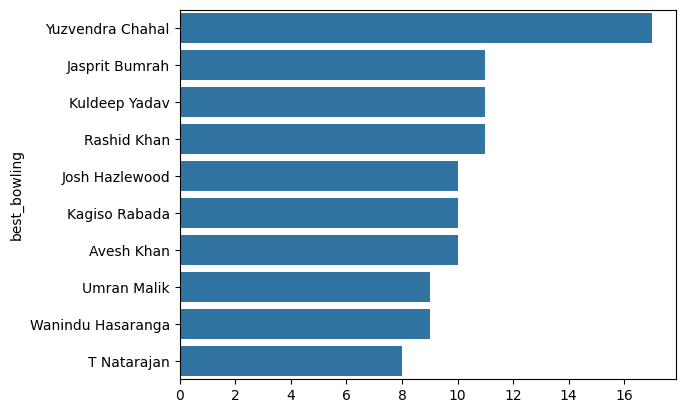

In [137]:
# df['best_bowling']
df['most_wickets']=df['best_bowling_figure'].apply(lambda x:x.split("--")[0])
df['most_wickets']=df['most_wickets'].astype(int)
best=df.groupby("best_bowling")['most_wickets'].sum().sort_values(ascending=False).head(10)
best
sns.barplot(x=best.values,y=best.index)


In [141]:

df['most_wickets']=df['best_bowling_figure'].apply(lambda x:x.split("--")[0])
df['most_wickets']=df['most_wickets'].astype(int)
top_bowlers=df.groupby("best_bowling")['most_wickets'].sum().sort_values(ascending=False).head(10)
fig=px.bar(top_bowlers,y=top_bowlers.index,x=top_bowlers.values,color_discrete_sequence=["orange"],title="Best Bowling Figures in IPL")
fig.show()


<h5 style="font-weight:500;">  Venue Analysis  </h5>

<p style="font-weight:500; font-size:17px">  Most Matches played by venue  </p>

In [142]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure', 'most_wickets'],
      dtype='str')

In [145]:
df['venue'].value_counts()

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

In [148]:


venues=df['venue'].value_counts()
fig=px.bar(venues,y=venues.index,x=venues.values,color_discrete_sequence=["orange"],title="Most Popular Venues in IPL")
fig.show()

<Axes: ylabel='venue'>

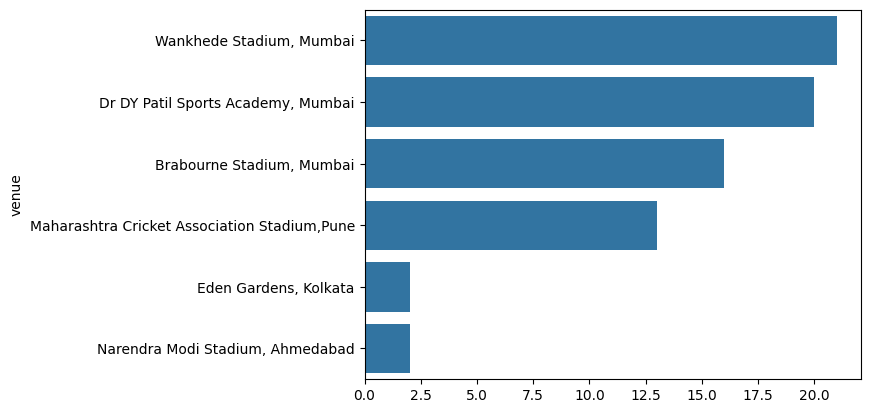

In [149]:


venues=df['venue'].value_counts()
sns.barplot(y=venues.index,x=venues.values)

<h5 style="font-weight:500;">  Custom Questions and Insights  </h5>

<p style="font-weight:500; font-size:17px">  1. Who won the highest margin by runs  </p>

In [150]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure', 'most_wickets'],
      dtype='str')

In [157]:
df[df['won_by']=="Runs"].sort_values(by="margin",ascending=False).head(1)[['match_winner','margin']]


,match_winner,margin
54,Chennai,91


<p style="font-weight:500; font-size:17px">  2. Which player has highest individual score
  </p>

In [179]:
df[df['highscore']==df['highscore'].max()]

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,most_wickets
65,66,"May 18,2022","Dr DY Patil Sports Academy, Mumbai",Kolkata,Lucknow,Group,Lucknow,Bat,210,0,...,8,Lucknow,Runs,2,Quinton de Kock,Quinton de Kock,140,Mohsin Khan,3--20,3


<p style="font-weight:500; font-size:17px">  3. Which bowler has best bowling figures
  </p>

In [180]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure', 'most_wickets'],
      dtype='str')

In [191]:
df[df['most_wickets']==df['most_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
